<a href="https://colab.research.google.com/github/semthedev/neural-fca/blob/main/big_hw_syimyk_khamdamov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural FCA - Big Homework Solution (10/10)
Syimyk Khamdamov

**Course:** Ordered Sets in Data Analysis (HSE)
**Task:** Interpretable Classification with Neural FCA

This notebook contains a complete solution, including:
1.  **Choose a dataset** (Kaggle, etc.), define the target attribute, binarize data and describe scaling (binarization) strategy for the dataset features. (Ideal dataset: openly available, with various data types with hundreds of rows.)
2. **Perform classification using standard ML tools** (at least 4), explain your choice. For example:
K Nearest Neighbor (kNN)
Naive Bayes
Logistic Regression
SVM
Decision Tree
Random Forest
XGBoost
3. **Describe prediction quality measure best suited for the dataset** (e.g. accuracy, F1 score, or any quality measure best suited for the dataset); fit and test the network on your task.
4. **Try to improve the basic baseline with different ways such that:**
- better scaling algorithm to binarize the original data;
- use various techniques to select best concepts from the concept lattice;
- propose your own modification of this nn's architecture.
5. **Submit a report with comparison of all models**, both standard and developed by you. Analyse your results.


**Grading system (out of 10):**

- Performing steps 1-5 grants a maximum of 1/10.
- Improving of the performance grants a maximum of 2/10.
- Proper report with analysis of the results grants a maximum of 3/10.
- Improving the nn's architecture grants a maximum of 1/10.
- Presenting the work grants a maximum of 3/10.

Total: 10

# Choose a dataset

[Dataset](https://www.kaggle.com/datasets/ahsan81/superstore-marketing-campaign-dataset)

Context- A superstore is planning for the year-end sale. They want to launch a new offer - gold membership, that gives a 20% discount on all purchases, for only \$499 which is $999 on other days. It will be valid only for existing customers and the campaign through phone calls is currently being planned for them. The management feels that the best way to reduce the cost of the campaign is to make a predictive model which will classify customers who might purchase the offer.
Objective - The superstore wants to predict the likelihood of the customer giving a positive response and wants to identify the different factors which affect the customer's response. You need to analyze the data provided to identify these factors and then build a prediction model to predict the probability of a customer will give a positive response.

# Data Preparation and EDA

In [6]:
!pip install optuna
!pip install fcapy[all]
!pip install frozendict
!pip install ipynb
!pip install sparselinear
!pip install bitsets
!pip install bitarray
import torch
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cuda118.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cuda118.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.0.0+cuda118.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cuda118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=664339 sha256=26a46e07f90b8641fee4a905722cf40d4462fd12bb85077dd40ad923d8462859
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
Successfully built torch-scatter
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cuda118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1221952 sha256=62c7fede7dea62a200fb074eeb7e394eafc4fd8660120a93ed5ebb6c3aaacbac
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
Successfully built 

In [7]:
%cd "/content/drive/MyDrive/1 семестр HSE DS 2025/OSDA"
!ls

/content/drive/MyDrive/1 семестр HSE DS 2025/OSDA
 big_hw_syimyk_khamdamov.ipynb	 superstore_data.csv
'Copy_of_res2 (1).ipynb'	 superstore-marketing-campaign-dataset.zip
 house-votes-84.csv		 Upgraded_version_House_Votes-example.ipynb
 neural_lib58.py		 Upgraded_version_House_Votes-exampleipynb
 __pycache__


In [10]:
import sys
sys.path.append("/content/drive/MyDrive/1 семестр HSE DS 2025/OSDA/neural_lib58.py")

In [12]:
import neural_lib58 as nl

import sys, subprocess, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler

import optuna
from optuna import Trial
from optuna.samplers import TPESampler

from fcapy.context import FormalContext
from fcapy.lattice import ConceptLattice

from fcapy.visualizer import LineVizNx


In [13]:
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ahsan81/superstore-marketing-campaign-dataset
!unzip -o superstore-marketing-campaign-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ahsan81/superstore-marketing-campaign-dataset
License(s): CC0-1.0
superstore-marketing-campaign-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  superstore-marketing-campaign-dataset.zip
  inflating: superstore_data.csv     


In [14]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv('superstore_data.csv')
df = raw_df.copy()
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

ID - unique client identifier.

Year_Birth - client’s year of birth (used to calculate age).

Education - client’s education level: Graduation, PhD, 2n Cycle, Master, Basic.

Marital - client’s marital status: Divorced, Single, Married, Together, Widow, YOLO, Alone, Absurd.

Income - client household’s annual income.

Kidhome — number of small children in the client’s household. (0, 1, 2)

Teenhome — number of teenagers in the client’s household. (0, 1, 2)

Dt_Customer — date when the client registered with the company (month/day/year).

Recency — number of days since the last purchase (0…99).

MntWines — amount spent on wine products in the last 2 years.

MntFruits — amount spent on fruits in the last 2 years.

MntMeatProducts — amount spent on meat products in the last 2 years.

MntFishProducts — amount spent on fish products in the last 2 years.

MntSweetProducts — amount spent on sweets in the last 2 years.

MntGoldProds — amount spent on gold products in the last 2 years.

NumDealsPurchases — number of purchases made with discounts.

NumWebPurchases — number of purchases made on the company’s website.

NumCatalogPurchases — number of purchases made via catalog (items shipped by mail).

NumStorePurchases — number of purchases made directly in physical stores.

NumWebVisitsMonth — number of visits to the company’s website during the last month.

Response (target variable) — 1 if the client accepted the offer in the last campaign, 0 otherwise.

Complain — 1 if the client has complained in the last 2 years, 0 otherwise.

In [16]:
cols = [
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

for col in cols:
    uniq_vals = np.sort(df[col].unique())
    print(f'\n{col}')
    print('Unique values:', uniq_vals)
    print('Number of unique values:', len(uniq_vals))


NumDealsPurchases
Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15]
Number of unique values: 15

NumWebPurchases
Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 23 25 27]
Number of unique values: 15

NumCatalogPurchases
Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 22 28]
Number of unique values: 14

NumStorePurchases
Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Number of unique values: 14

NumWebVisitsMonth
Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 13 14 17 19 20]
Number of unique values: 16


## Missing values in Income/ replacement with median

In [17]:
df.isna().sum(axis=0)/len(df)

,0
Id,0.000000
Year_Birth,0.000000
Education,0.000000
Marital_Status,0.000000
Income,0.010714
Kidhome,0.000000
Teenhome,0.000000
Dt_Customer,0.000000
Recency,0.000000
MntWines,0.000000


In [18]:
mean_income = df['Income'].mean()
median_income = df['Income'].median()
mode_income = df['Income'].mode()[0]
print('Mean:' + str(mean_income))
print('Median:' + str(median_income))
print('Mode:' + str(mode_income))

Mean:52247.25135379061
Median:51381.5
Mode:7500.0


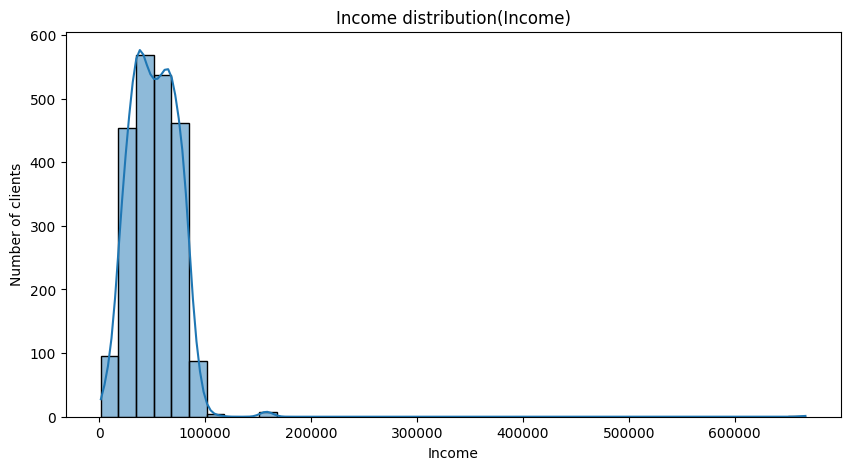

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['Income'].dropna(), kde=True, bins=40)
plt.title("Income distribution(Income)")
plt.xlabel("Income")
plt.ylabel("Number of clients")
plt.show()

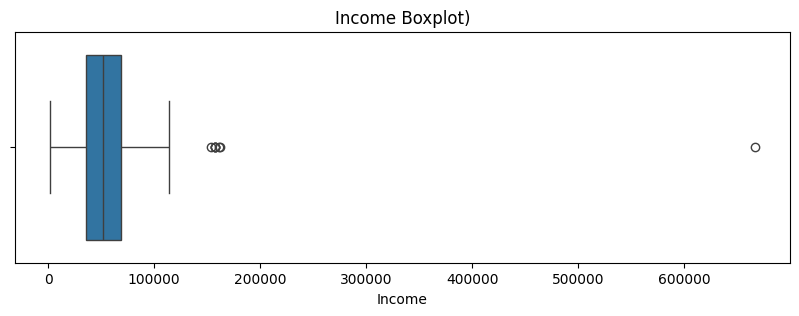

In [20]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Income'].dropna())
plt.title("Income Boxplot)")
plt.xlabel("Income")
plt.show()

In [21]:
df.loc[df.Income.isnull(), 'Income'] = np.nanmedian(df.Income)

df.isna().sum(axis=0)/len(df)

,0
Id,0.0
Year_Birth,0.0
Education,0.0
Marital_Status,0.0
Income,0.0
Kidhome,0.0
Teenhome,0.0
Dt_Customer,0.0
Recency,0.0
MntWines,0.0


In [22]:
# there are no duplicates
df.duplicated().sum()

np.int64(0)

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


## Income / Year_Birth

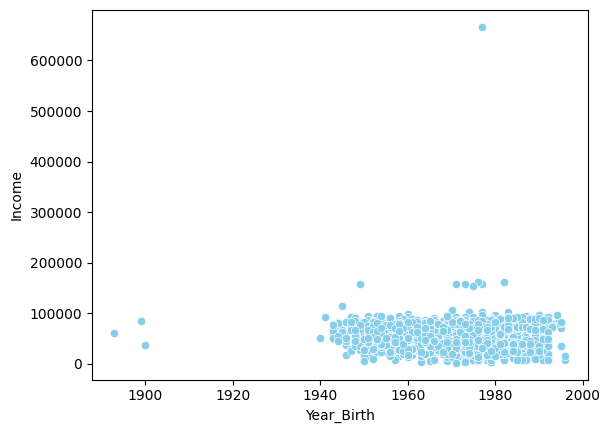

In [24]:
fig, ax = plt.subplots()

sns.scatterplot(df, x='Year_Birth', y='Income', ax=ax, color='skyblue')

plt.show()

In [25]:
df[df.Year_Birth <= 1900]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
513,11004,1893,2n Cycle,Single,60182.0,0,1,5/17/2014,23,8,...,7,0,2,1,1,0,2,4,0,0
827,1150,1899,PhD,Together,83532.0,0,0,9/26/2013,36,755,...,104,64,224,1,4,6,4,1,0,0
2233,7829,1900,2n Cycle,Divorced,36640.0,1,0,9/26/2013,99,15,...,7,4,25,1,2,1,2,5,0,1


In the Year_Birth column, there is a significant time gap between 1900 and 1940, in which there is not a single value. In addition, there are only three clients born before 1901. These values are definitely outliers, and there is a possibility that a data entry error occurred in these cases.

There is also one value in the Income column that deviates markedly from the expected distribution.

These values in both columns need to be processed so that they do not have a negative impact on analytics and, more importantly, on our model.

In [26]:
# we delete such values

df.drop(df.index[df.Year_Birth <= 1900], inplace=True)
df.drop(df.index[df.Income > 300000], inplace=True)

In [27]:
import datetime

current_year = datetime.datetime.now().year
df['Age'] = current_year - df['Year_Birth']
df = df.drop(columns=['Year_Birth'])

In [28]:
df.head()

,Id,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,104,...,189,218,1,4,4,6,1,1,0,55
1,1,Graduation,Single,57091.0,0,0,6/15/2014,0,464,5,...,0,37,1,7,3,7,5,1,0,64
2,10476,Graduation,Married,67267.0,0,1,5/13/2014,0,134,11,...,2,30,1,3,2,5,2,0,0,67
3,1386,Graduation,Together,32474.0,1,1,11/5/2014,0,10,0,...,0,0,1,1,0,2,7,0,0,58
4,5371,Graduation,Single,21474.0,1,0,8/4/2014,0,6,16,...,0,34,2,3,1,2,7,1,0,36


## Mnt

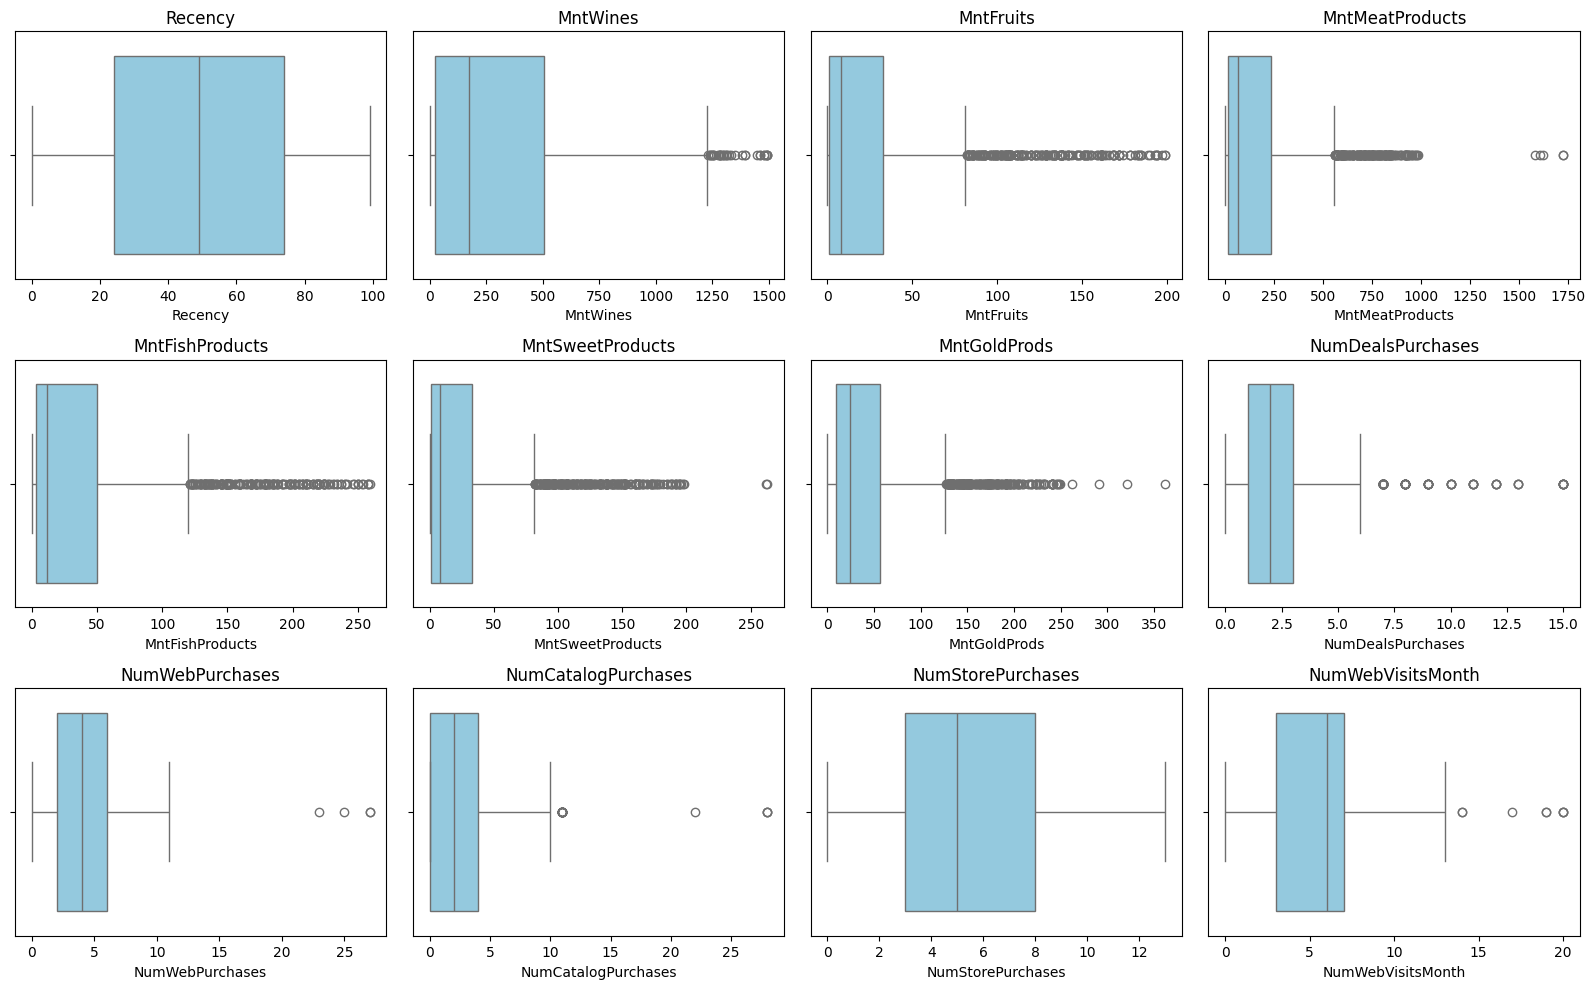

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

list_boxplots = [
    'Recency', 'MntWines', 'MntFruits',
    'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
    'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))

axes = axes.ravel()

for idx, col in enumerate(list_boxplots):
    sns.boxplot(x=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(col)

plt.tight_layout()
plt.show()


In [30]:
df.drop(df.index[df.MntMeatProducts > 1200], inplace=True)
df.drop(df.index[df.MntSweetProducts > 240], inplace=True)
df.drop(df.index[df.MntGoldProds > 270], inplace=True)

In [31]:
df.shape

(2227, 22)

13 samples were discarded compared to the original dataset

Now we can draw conclusions without worrying about sudden deviations.

## Percentage of Negative and Positive Response from the Marketing Campaign

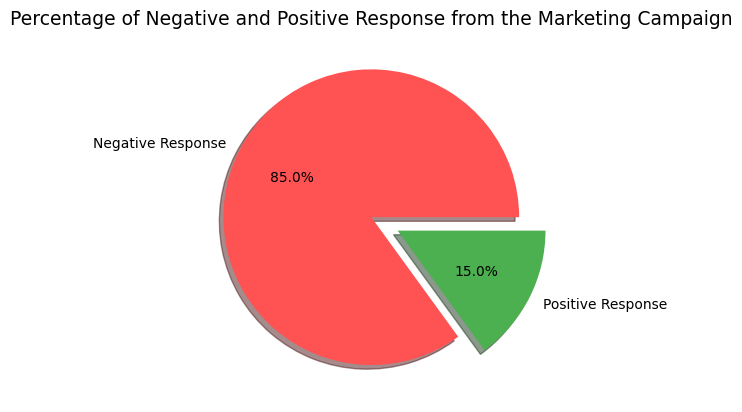

In [32]:
fig, ax = plt.subplots()

ax.pie(
    df.Response.value_counts().values,
    labels=["Negative Response","Positive Response"],
    autopct="%1.1f%%",
    explode=(0, 0.2),
    shadow=True,
    colors=['#FF5252', '#4CAF50']
)

ax.set_title('Percentage of Negative and Positive Response from the Marketing Campaign', fontsize=13.5)

plt.show()

Our dataset suffers from Unbalanced classes with only 15% of customers providing a positive response, before modeling, we need balance the data to avoid favoring the majority class.

In [33]:
response_date = df.groupby('Dt_Customer')['Response'].mean().reset_index()
response_date['Dt_Customer'] = response_date.Dt_Customer.astype(str)

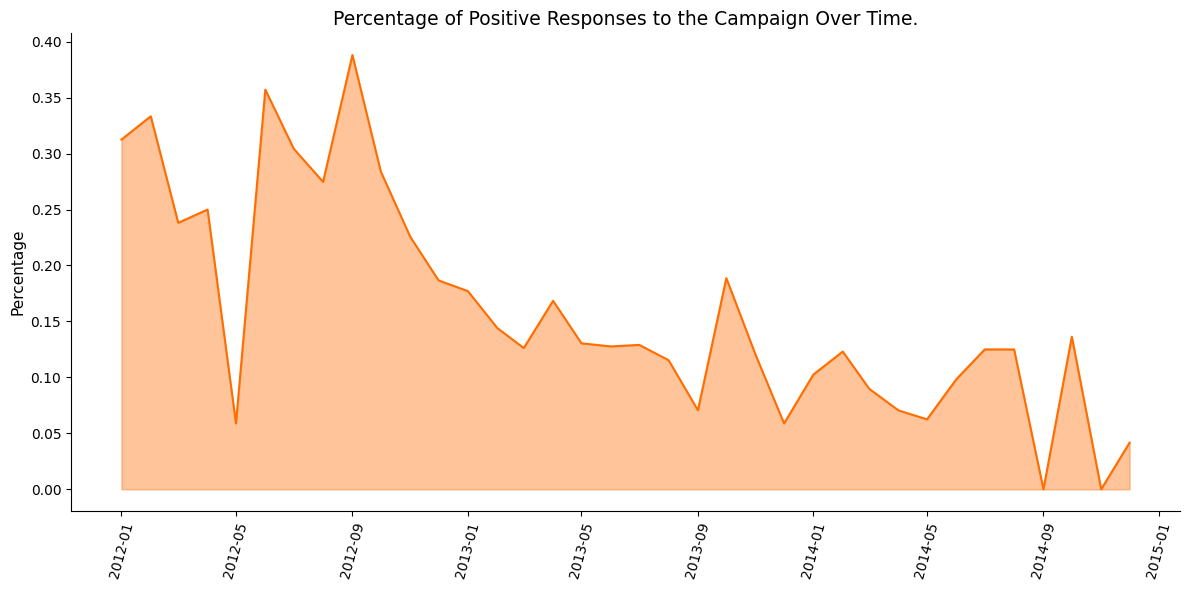

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Dt_month'] = df['Dt_Customer'].dt.to_period('M').dt.to_timestamp()

response_date = (
    df.groupby('Dt_month')['Response']
      .mean()
      .reset_index()
      .sort_values('Dt_month')
)

fig, ax = plt.subplots(figsize=(12, 6))

y = response_date['Response']

ax.plot(response_date['Dt_month'], y, color='#ff6d00')
ax.fill_between(response_date['Dt_month'], y, color='#ff6d00', alpha=0.4)

ax.tick_params(axis='x', rotation=75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Percentage of Positive Responses to the Campaign Over Time.', fontsize=13.5)
ax.set_ylabel('Percentage', fontsize=11)
ax.set_xlabel('')

plt.tight_layout()
plt.show()


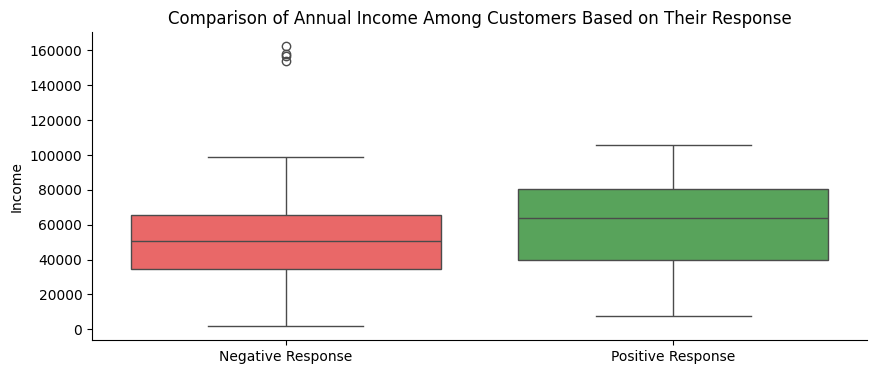

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(df, x='Response', y='Income', ax=ax, palette=['#FF5252', '#4CAF50'])

ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Comparison of Annual Income Among Customers Based on Their Response', fontsize=12)

ax.set_xticklabels(['Negative Response', 'Positive Response'])
ax.set_xlabel('')

plt.show()


## Dt_Customer

In [36]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
ref_date = df["Dt_Customer"].max()
df["Tenure_days"]  = (ref_date - df["Dt_Customer"]).dt.days
df["Tenure_years"] = df["Tenure_days"] / 365.25
df.drop('Dt_Customer', axis=1, inplace=True)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2227 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   2227 non-null   int64         
 1   Education            2227 non-null   object        
 2   Marital_Status       2227 non-null   object        
 3   Income               2227 non-null   float64       
 4   Kidhome              2227 non-null   int64         
 5   Teenhome             2227 non-null   int64         
 6   Recency              2227 non-null   int64         
 7   MntWines             2227 non-null   int64         
 8   MntFruits            2227 non-null   int64         
 9   MntMeatProducts      2227 non-null   int64         
 10  MntFishProducts      2227 non-null   int64         
 11  MntSweetProducts     2227 non-null   int64         
 12  MntGoldProds         2227 non-null   int64         
 13  NumDealsPurchases    2227 non-null   i

## Kidhome / Teenhome

In [38]:
# The signs of Kidhome and Teenhome can be summed up in the total number of children in the family.
df["Children"] = df["Kidhome"].fillna(0) + df["Teenhome"].fillna(0)
df = df.drop(columns=["Kidhome", "Teenhome"])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2227 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   2227 non-null   int64         
 1   Education            2227 non-null   object        
 2   Marital_Status       2227 non-null   object        
 3   Income               2227 non-null   float64       
 4   Recency              2227 non-null   int64         
 5   MntWines             2227 non-null   int64         
 6   MntFruits            2227 non-null   int64         
 7   MntMeatProducts      2227 non-null   int64         
 8   MntFishProducts      2227 non-null   int64         
 9   MntSweetProducts     2227 non-null   int64         
 10  MntGoldProds         2227 non-null   int64         
 11  NumDealsPurchases    2227 non-null   int64         
 12  NumWebPurchases      2227 non-null   int64         
 13  NumCatalogPurchases  2227 non-null   i

In [40]:
# dropping the 'Id' column
df.drop('Id', axis=1, inplace=True)

In [41]:
#df = pd.get_dummies(df) #get_dummies() - для стандартизации
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2227 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Education            2227 non-null   object        
 1   Marital_Status       2227 non-null   object        
 2   Income               2227 non-null   float64       
 3   Recency              2227 non-null   int64         
 4   MntWines             2227 non-null   int64         
 5   MntFruits            2227 non-null   int64         
 6   MntMeatProducts      2227 non-null   int64         
 7   MntFishProducts      2227 non-null   int64         
 8   MntSweetProducts     2227 non-null   int64         
 9   MntGoldProds         2227 non-null   int64         
 10  NumDealsPurchases    2227 non-null   int64         
 11  NumWebPurchases      2227 non-null   int64         
 12  NumCatalogPurchases  2227 non-null   int64         
 13  NumStorePurchases    2227 non-null   i

ValueError: could not convert string to float: 'Graduation'

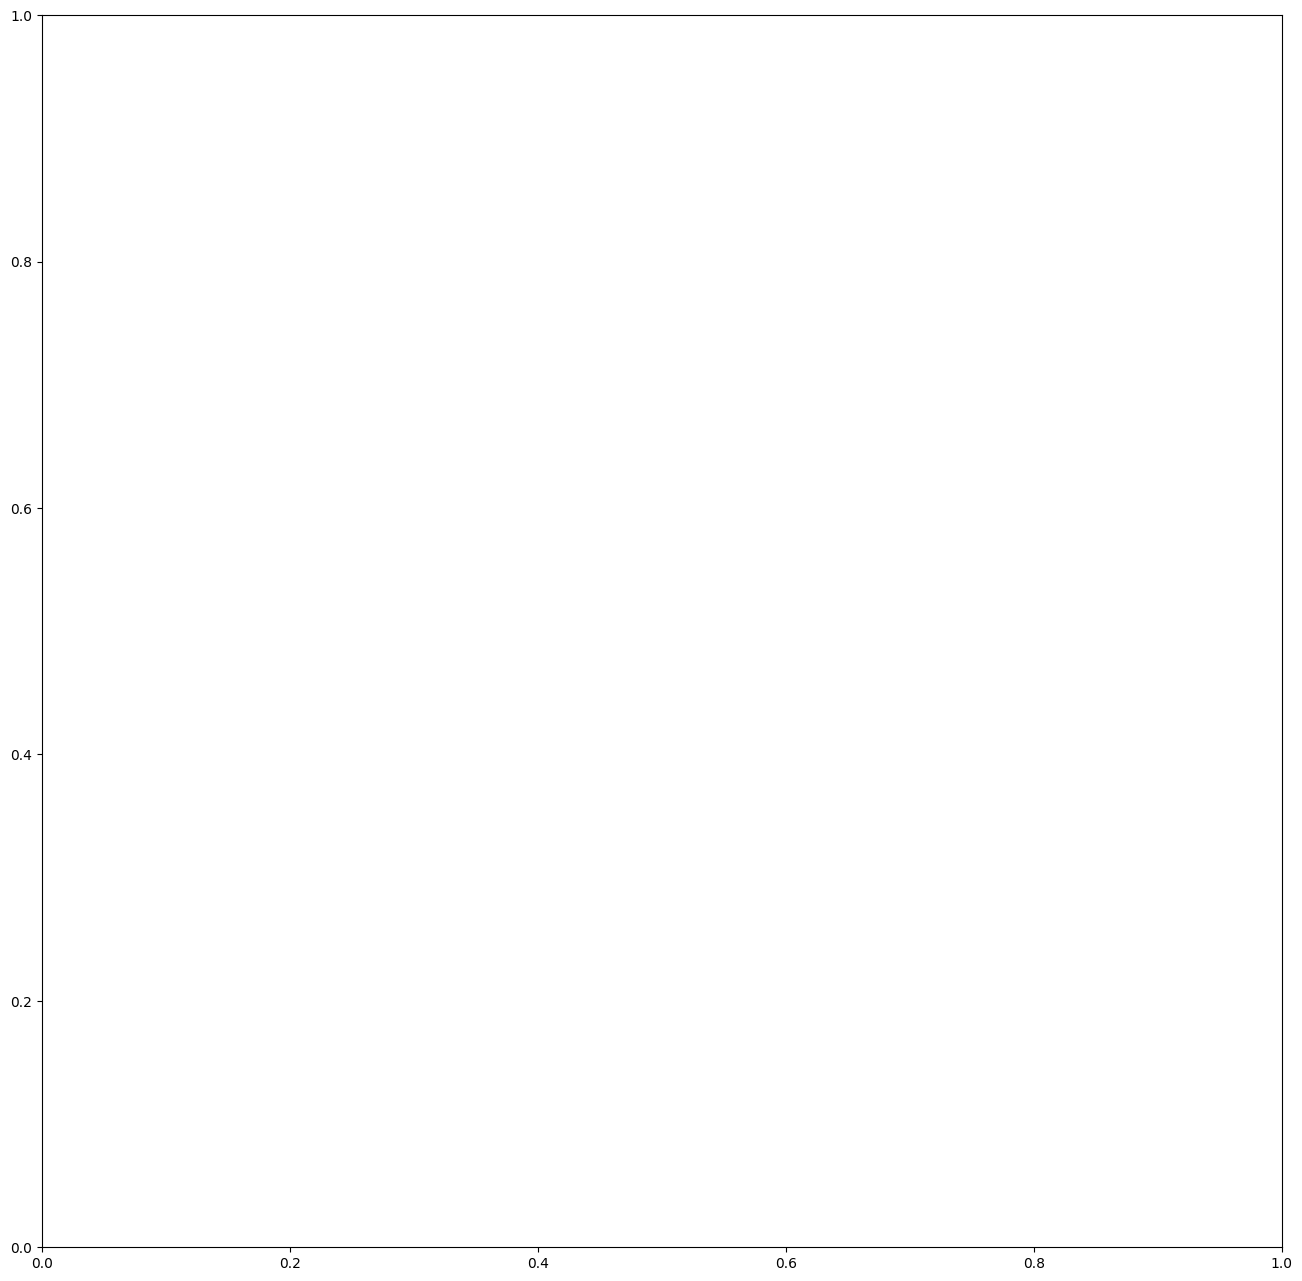

In [43]:
fig, ax = plt.subplots(figsize=(16, 16))

sns.heatmap(df.corr(), ax=ax, cmap='crest')

plt.show()

Now, we need to:

Standardizing the data

Split the data into training and testing sets

And Balance the data

# Logistic Regression, kNN, Random Forest и XGBoost

In [46]:
df_model = df.drop(columns=['Dt_month', 'Tenure_days'])

target = "Response"
y = df[target].astype(int)

categorical_features = ['Education', 'Marital_Status', 'Complain', 'Children']

numeric_features = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Tenure_years']

# drop_cols = [c for c in ["Dt_Customer","Year_Birth"] if c in df.columns]
# X = df.drop(columns=[target] + drop_cols)

feature_cols = numeric_features + categorical_features
X = df[feature_cols].copy()

In [47]:
# 2) unified train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Preprocessors for models
pre_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop'
)

# for xgboost
pre_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop'
)


In [48]:
# 4) Optuna Settings
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score)

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = TPESampler(seed=42)

N_TRIALS_LR  = 60
N_TRIALS_KNN = 60
N_TRIALS_RF  = 80
N_TRIALS_XGB = 80

# 5) Objective Optuna
def objective_logreg(trial: Trial):
    penalty = trial.suggest_categorical("penalty", ["l2", "l1"])
    solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear", "saga"])
    if penalty == "l1" and solver == "lbfgs":
        raise optuna.TrialPruned()

    C = trial.suggest_float("C", 1e-2, 10.0, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    clf = Pipeline(steps=[
        ('pre', pre_scaled),
        ('clf', LogisticRegression(
            penalty=penalty,
            solver=solver,
            C=C,
            class_weight=class_weight,
            max_iter=2000,
            random_state=42,
            n_jobs=None if solver in ["liblinear"] else None
        ))
    ])
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring=f1_scorer, n_jobs=-1)
    return scores.mean()

def objective_knn(trial: Trial):
    n_neighbors = trial.suggest_int("n_neighbors", 3, 35, step=2)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_categorical("p", [1, 2])  # манхэттен/эвклид

    clf = Pipeline(steps=[
        ('pre', pre_scaled),
        ('clf', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p))
    ])
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring=f1_scorer, n_jobs=-1)
    return scores.mean()

def objective_rf(trial: Trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 600, step=100)
    max_depth    = trial.suggest_categorical("max_depth", [None, 5, 8, 12])
    min_leaf     = trial.suggest_categorical("min_samples_leaf", [1, 3, 5])
    max_features = trial.suggest_categorical("max_features", ["sqrt", 0.5, 1.0])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"])

    clf = Pipeline(steps=[
        ('pre', pre_tree),
        ('clf', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=42,
            n_jobs=-1
        ))
    ])
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring=f1_scorer, n_jobs=-1)
    return scores.mean()

def objective_xgb(trial: Trial):
    counts = y_train.value_counts()
    neg_pos_ratio = counts.get(0, 0) / max(1, counts.get(1, 1))

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "max_depth": trial.suggest_int("max_depth", 1, 8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            max(1.0, 0.5 * neg_pos_ratio),
            2.0 * neg_pos_ratio,
        ),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
    }

    clf = Pipeline(steps=[
        ('pre', pre_tree),
        ('clf', XGBClassifier(**params)),
    ])

    scores = cross_val_score(
        clf,
        X_train, y_train,
        cv=cv,
        scoring=f1_scorer,
        n_jobs=-1
    )
    return scores.mean()

In [49]:
# 6) Launching Optuna
studies = {}

studies["Logistic Regression"] = optuna.create_study(direction="maximize", sampler=sampler)
studies["Logistic Regression"].optimize(objective_logreg, n_trials=N_TRIALS_LR, show_progress_bar=False)

studies["kNN"] = optuna.create_study(direction="maximize", sampler=sampler)
studies["kNN"].optimize(objective_knn, n_trials=N_TRIALS_KNN, show_progress_bar=False)

studies["Random Forest"] = optuna.create_study(direction="maximize", sampler=sampler)
studies["Random Forest"].optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=False)

studies["XGBoost"] = optuna.create_study(direction="maximize", sampler=sampler)
studies["XGBoost"].optimize(objective_xgb, n_trials=N_TRIALS_XGB, show_progress_bar=False)

studies["XGBoost"] = optuna.create_study(
    direction="maximize",
    sampler=sampler
)
studies["XGBoost"].optimize(
    objective_xgb,
    n_trials=N_TRIALS_XGB,
    show_progress_bar=False
)

In [50]:
# 7) We train the best pipelines and count F1 on the TEST
best_test_scores = {}

best_lr = studies["Logistic Regression"].best_params
penalty = best_lr["penalty"]
solver = best_lr["solver"]
if penalty == "l1" and solver not in ["liblinear","saga"]:
    solver = "saga"
lr_clf = Pipeline(steps=[
    ('pre', pre_scaled),
    ('clf', LogisticRegression(
        penalty=penalty,
        solver=solver,
        C=best_lr["C"],
        class_weight=best_lr["class_weight"],
        max_iter=2000,
        random_state=42
    ))
])
lr_clf.fit(X_train, y_train)
best_test_scores["Logistic Regression"] = f1_score(y_test, lr_clf.predict(X_test))

# kNN
best_knn = studies["kNN"].best_params
knn_clf = Pipeline(steps=[
    ('pre', pre_scaled),
    ('clf', KNeighborsClassifier(
        n_neighbors=best_knn["n_neighbors"],
        weights=best_knn["weights"],
        p=best_knn["p"]
    ))
])
knn_clf.fit(X_train, y_train)
best_test_scores["kNN"] = f1_score(y_test, knn_clf.predict(X_test))

# Random Forest
best_rf = studies["Random Forest"].best_params
rf_clf = Pipeline(steps=[
    ('pre', pre_tree),
    ('clf', RandomForestClassifier(
        n_estimators=best_rf["n_estimators"],
        max_depth=best_rf["max_depth"],
        min_samples_leaf=best_rf["min_samples_leaf"],
        max_features=best_rf["max_features"],
        class_weight=best_rf["class_weight"],
        random_state=42,
        n_jobs=-1
    ))
])
rf_clf.fit(X_train, y_train)
best_test_scores["Random Forest"] = f1_score(y_test, rf_clf.predict(X_test))

# # XGBoost
best_xgb = studies["XGBoost"].best_params

xgb_best = Pipeline(steps=[
    ('pre', pre_tree),
    ('clf', XGBClassifier(
        **best_xgb,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    ))
])

xgb_best.fit(X_train, y_train)
best_test_scores["XGBoost"] = f1_score(y_test, xgb_best.predict(X_test))

In [51]:
# 8) Results
print("\n Best parameters (F1) ")
for name, st in studies.items():
    print(f"\n{name}: best CV-F1={st.best_value:.4f}")
    print(st.best_params)

print("\n F1 на TEST ")
res_df = pd.DataFrame([
    {"Model": k, "F1_test": round(v, 4)} for k, v in best_test_scores.items()
]).sort_values("F1_test", ascending=False)
print(res_df.to_string(index=False))


 Best parameters (F1) 

Logistic Regression: best CV-F1=0.4815
{'penalty': 'l2', 'solver': 'saga', 'C': 0.015557728663374381, 'class_weight': 'balanced'}

kNN: best CV-F1=0.3465
{'n_neighbors': 3, 'weights': 'uniform', 'p': 2}

Random Forest: best CV-F1=0.5332
{'n_estimators': 400, 'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'class_weight': 'balanced_subsample'}

XGBoost: best CV-F1=0.5568
{'n_estimators': 782, 'learning_rate': 0.038417977257180824, 'subsample': 0.6170501044317374, 'max_depth': 2, 'colsample_bytree': 0.9974475071088733, 'min_child_weight': 7, 'gamma': 1.5021545135319627, 'reg_alpha': 0.5708973232438783, 'reg_lambda': 3.603280273747761, 'scale_pos_weight': 8.233187029785878}

 F1 на TEST 
              Model  F1_test
      Random Forest   0.5780
            XGBoost   0.5775
Logistic Regression   0.5279
                kNN   0.2947


# NN FCA

In [61]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score

from imblearn.over_sampling import RandomOverSampler

from fcapy.context import FormalContext
from fcapy.lattice import ConceptLattice

import neural_lib58 as nl

In [62]:
df.head()

,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Dt_month,Tenure_days,Tenure_years,Children
0,Graduation,Divorced,84835.0,0,189,104,379,111,189,218,...,4,6,1,1,0,55,2014-06-01,173,0.473648,0
1,Graduation,Single,57091.0,0,464,5,64,7,0,37,...,3,7,5,1,0,64,2014-06-01,174,0.476386,0
2,Graduation,Married,67267.0,0,134,11,59,15,2,30,...,2,5,2,0,0,67,2014-05-01,207,0.566735,1
3,Graduation,Together,32474.0,0,10,0,1,0,0,0,...,0,2,7,0,0,58,2014-11-01,31,0.084873,2
4,Graduation,Single,21474.0,0,6,16,24,11,0,34,...,1,2,7,1,0,36,2014-08-01,124,0.339493,1


In [72]:
df_model = df.drop(columns=['Dt_month', 'Tenure_days'])

target = "Response"
y = df_model[target].astype(int)

categorical_features = ['Education', 'Marital_Status', 'Complain', 'Children']

numeric_features = [
    'Income', 'Recency', 'MntWines', 'MntFruits',
    'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth',
    'Age', 'Tenure_years'
]

feature_cols = numeric_features + categorical_features
X = df_model[feature_cols].copy()


In [73]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train y:", y_train.value_counts())
print("Test  y:", y_test.value_counts())

Train y: Response
0    1514
1     267
Name: count, dtype: int64
Test  y: Response
0    379
1     67
Name: count, dtype: int64


In [74]:
# Numerical transformer KBinsDiscretizer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(
        n_bins=3,
        encode='onehot-dense',
        strategy='quantile'
    ))
])

# Categorical Transformer OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_bin = preprocessor.fit_transform(X_train_raw)
X_test_bin  = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_full = pd.DataFrame(
    X_train_bin,
    columns=feature_names,
    index=X_train_raw.index
).astype(bool)

X_test_full = pd.DataFrame(
    X_test_bin,
    columns=feature_names,
    index=X_test_raw.index
).astype(bool)

print("Original shape:", df_model.shape)
print("Binary shape (train):", X_train_full.shape)
print("Binary shape (test): ", X_test_full.shape)


Original shape: (2227, 20)
Binary shape (train): (1781, 64)
Binary shape (test):  (446, 64)


In [75]:
ros = RandomOverSampler(random_state=42)
X_train_full_bal, y_train_bal = ros.fit_resample(X_train_full, y_train)

print("Before balance:", y_train.value_counts())
print("After balance :", y_train_bal.value_counts())
print("Shapes train_bal / test:", X_train_full_bal.shape, X_test_full.shape)


Before balance: Response
0    1514
1     267
Name: count, dtype: int64
After balance : Response
0    1514
1    1514
Name: count, dtype: int64
Shapes train_bal / test: (3028, 64) (446, 64)


In [80]:
corrs = {}
y_arr = y_train_bal.to_numpy()

for col in X_train_full_bal.columns:
    x = X_train_full_bal[col].astype(int).to_numpy()
    if x.std() == 0:
        corrs[col] = 0.0
    else:
        c = np.corrcoef(x, y_arr)[0, 1]
        corrs[col] = abs(c)

sorted_attrs = sorted(corrs.keys(), key=lambda c: corrs[c], reverse=True)

k = 10
attr_subset_size = min(k, len(sorted_attrs))
attrs_fca = sorted_attrs[:attr_subset_size]

print("Top attributes for FCA:")
for a in attrs_fca:
    print(f"  {a}: |corr|={corrs[a]:.3f}")




Top attributes for FCA:
  num__NumCatalogPurchases_0.0: |corr|=0.298
  num__MntGoldProds_0.0: |corr|=0.287
  cat__Children_0: |corr|=0.269
  num__MntMeatProducts_0.0: |corr|=0.255
  num__NumCatalogPurchases_2.0: |corr|=0.243
  num__MntWines_2.0: |corr|=0.240
  num__Tenure_years_2.0: |corr|=0.232
  num__Recency_0.0: |corr|=0.223
  num__Income_2.0: |corr|=0.222
  num__MntMeatProducts_2.0: |corr|=0.217


In [81]:
X_train_fca = X_train_full_bal[attrs_fca]
X_test_fca  = X_test_full[attrs_fca]

print("Shape X_train_fca:", X_train_fca.shape)
print("Shape X_test_fca :", X_test_fca.shape)


Shape X_train_fca: (3028, 10)
Shape X_test_fca : (446, 10)


In [78]:
# # we can try to use all binary attributes instead of correlation selection
# attrs_fca = X_train_full_bal.columns.tolist()

# X_train_fca = X_train_full_bal.copy()
# X_test_fca  = X_test_full.copy()

# print("Shape X_train_fca:", X_train_fca.shape)
# print("Shape X_test_fca :", X_test_fca.shape)
# print("Num attrs for FCA:", len(attrs_fca))


Shape X_train_fca: (3028, 64)
Shape X_test_fca : (446, 64)
Num attrs for FCA: 64


In [82]:
subset_size = 60
X_fca = X_train_fca.sample(
    n=min(subset_size, len(X_train_fca)),
    replace=False,
    random_state=42
)
y_fca = y_train_bal.loc[X_fca.index]

print(f"Subset for FCA: objects={len(X_fca)}, attrs={len(attrs_fca)}")

X_fca_ctx = X_fca.copy()
X_fca_ctx.index = X_fca_ctx.index.astype(str)

K_train = FormalContext.from_pandas(X_fca_ctx)
L = ConceptLattice.from_context(K_train, is_monotone=True)
print(f"Lattice size: {len(L)}")

y_fca_arr = y_fca.to_numpy()
concept_f1 = np.zeros(len(L))

for i, c in enumerate(L):
    y_pred = np.zeros_like(y_fca_arr)
    y_pred[list(c.extent_i)] = 1
    score = f1_score(y_fca_arr, y_pred)
    c.measures["f1_score"] = score
    concept_f1[i] = score

n_concepts = 15
best_concept_idx = concept_f1.argsort()[::-1][:n_concepts].tolist()

print(f"Top {n_concepts} concepts by F1:", best_concept_idx)

for idx in best_concept_idx:
    c = L[idx]
    print(f"Concept #{idx}: F1={c.measures['f1_score']:.3f}, intent={c.intent}")


Subset for FCA: objects=60, attrs=10
Lattice size: 334
Top 15 concepts by F1: [88, 192, 193, 211, 212, 213, 230, 138, 79, 191, 151, 59, 118, 107, 108]
Concept #88: F1=0.677, intent=('num__Tenure_years_2.0', 'num__Recency_0.0')
Concept #192: F1=0.667, intent=('cat__Children_0', 'num__Tenure_years_2.0', 'num__Recency_0.0')
Concept #193: F1=0.667, intent=('num__Tenure_years_2.0', 'num__Recency_0.0', 'num__Income_2.0')
Concept #211: F1=0.658, intent=('cat__Children_0', 'num__Tenure_years_2.0', 'num__Recency_0.0', 'num__MntMeatProducts_2.0')
Concept #212: F1=0.658, intent=('num__MntWines_2.0', 'num__Tenure_years_2.0', 'num__Recency_0.0', 'num__Income_2.0')
Concept #213: F1=0.658, intent=('cat__Children_0', 'num__NumCatalogPurchases_2.0', 'num__Tenure_years_2.0', 'num__Recency_0.0')
Concept #230: F1=0.649, intent=('cat__Children_0', 'num__NumCatalogPurchases_2.0', 'num__MntWines_2.0', 'num__Tenure_years_2.0', 'num__Recency_0.0', 'num__Income_2.0', 'num__MntMeatProducts_2.0')
Concept #138: F1

In [83]:
results_fca = {}

cn = nl.ConceptNetwork.from_lattice(
    lattice=L,
    best_concepts_indices=best_concept_idx,
    targets=tuple(sorted(set(y_train_bal)))
)

cn.fit(X_train_fca, y_train_bal, n_epochs=2000)

pred_prob  = cn.predict_proba(X_test_fca).detach().numpy()
pred_class = np.argmax(pred_prob, axis=1)

f1_nn = f1_score(y_test, pred_class)
print(f"Neural FCA (Base) F1: {f1_nn:.4f}")

results_fca['Neural FCA (Base)'] = f1_nn

Neural FCA (Base) F1: 0.3956


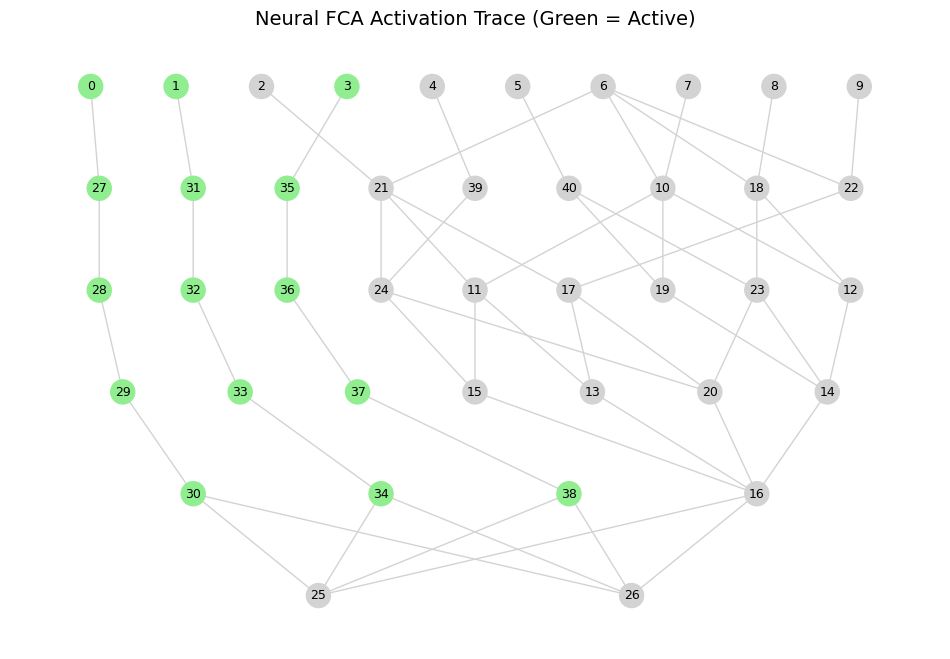

In [84]:
sample_idx = 0
row = X_test_fca.iloc[sample_idx]
sample_descr = set(row.index[row.astype(bool)])

traced = cn.trace_description(
    frozenset(sample_descr),
    include_targets=False
)

fig, ax = plt.subplots(figsize=(12, 8))
label_func = lambda el_i, P: f"{el_i}"

vis = LineVizNx(
    node_label_font_size=9,
    node_label_func=label_func
)

vis.draw_poset(
    cn.poset,
    ax=ax,
    flg_node_indices=False,
    node_color=[
        'lightgreen' if el_i in traced else 'lightgray'
        for el_i in range(len(cn.poset))
    ]
)

plt.title("Neural FCA Activation Trace (Green = Active)", fontsize=14)
plt.show()


**ниже старый код без баллансировки**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(
        n_bins=3,
        encode='onehot-dense',
        strategy='quantile'
    ))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_bin = preprocessor.fit_transform(X_train)
X_test_bin  = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_full = pd.DataFrame(
    X_train_bin,
    columns=feature_names,
    index=X_train.index
).astype(bool)

X_test_full = pd.DataFrame(
    X_test_bin,
    columns=feature_names,
    index=X_test.index
).astype(bool)

print(f"Original shape: {df.shape}")
print(f"Binary shape (train): {X_train_full.shape}")
print(f"Binary shape (test):  {X_test_full.shape}")

Original shape: (2227, 22)
Binary shape (train): (1781, 64)
Binary shape (test):  (446, 64)


In [ ]:
corrs = {}
y_arr = y_train.to_numpy()

for col in X_train_full.columns:
    x = X_train_full[col].astype(int).to_numpy()
    if x.std() == 0:
        corrs[col] = 0.0
    else:
        c = np.corrcoef(x, y_arr)[0, 1]
        corrs[col] = abs(c)

sorted_attrs = sorted(corrs.keys(), key=lambda c: corrs[c], reverse=True)

k = 20
attr_subset_size = min(k, len(sorted_attrs))
attrs_fca = sorted_attrs[:attr_subset_size]

print("Top attributes for FCA:")
for a in attrs_fca:
    print(f"  {a}: |corr|={corrs[a]:.3f}")

X_train_fca = X_train_full[attrs_fca]
X_test_fca  = X_test_full[attrs_fca]


Top attributes for FCA:
  cat__Children_0: |corr|=0.208
  num__MntGoldProds_0.0: |corr|=0.193
  num__NumCatalogPurchases_0.0: |corr|=0.185
  num__NumCatalogPurchases_2.0: |corr|=0.182
  num__MntWines_2.0: |corr|=0.179
  num__Tenure_years_2.0: |corr|=0.173
  num__MntMeatProducts_0.0: |corr|=0.171
  num__Income_2.0: |corr|=0.167
  num__NumWebPurchases_2.0: |corr|=0.164
  num__Recency_0.0: |corr|=0.160


In [ ]:
X_train_fca = X_train_full[attrs_fca]
X_test_fca  = X_test_full[attrs_fca]

print("Shape X_train_fca:", X_train_fca.shape)
print("Shape X_test_fca :", X_test_fca.shape)

subset_size = 60

X_fca = X_train_fca.sample(
    n=min(subset_size, len(X_train_fca)),
    replace=False,
    random_state=42
)
y_fca = y_train.loc[X_fca.index]

print(f"Subset for FCA: objects={len(X_fca)}, attrs={len(attrs_fca)}")

Shape X_train_fca: (1781, 10)
Shape X_test_fca : (446, 10)
Subset for FCA: objects=60, attrs=10


In [ ]:
X_fca_ctx = X_fca.copy()
X_fca_ctx.index = X_fca_ctx.index.astype(str)

K_train = FormalContext.from_pandas(X_fca_ctx)

L = ConceptLattice.from_context(K_train, is_monotone=True)
print(f"Lattice size: {len(L)}")

y_fca_arr = y_fca.to_numpy()
concept_f1 = np.zeros(len(L))

for i, c in enumerate(L):
    y_pred = np.zeros_like(y_fca_arr)
    y_pred[list(c.extent_i)] = 1

    score = f1_score(y_fca_arr, y_pred)
    c.measures["f1_score"] = score
    concept_f1[i] = score

n_concepts = 15
best_concept_idx = concept_f1.argsort()[::-1][:n_concepts].tolist()

print(f"Top {n_concepts} concepts by F1:", best_concept_idx)

for idx in best_concept_idx:
    c = L[idx]
    print(f"Concept #{idx}: F1={c.measures['f1_score']:.3f}, intent={c.intent}")


Lattice size: 393
Top 15 concepts by F1: [33, 36, 10, 22, 39, 41, 42, 25, 48, 58, 55, 8, 13, 67, 64]
Concept #33: F1=0.450, intent=('num__MntWines_2.0', 'num__NumWebPurchases_2.0')
Concept #36: F1=0.439, intent=('num__MntWines_2.0', 'num__Income_2.0', 'num__NumWebPurchases_2.0')
Concept #10: F1=0.438, intent=('num__MntWines_2.0',)
Concept #22: F1=0.432, intent=('num__Income_2.0', 'num__NumWebPurchases_2.0')
Concept #39: F1=0.429, intent=('num__MntWines_2.0', 'num__Recency_0.0')
Concept #41: F1=0.429, intent=('cat__Children_0', 'num__MntWines_2.0', 'num__Income_2.0', 'num__NumWebPurchases_2.0')
Concept #42: F1=0.429, intent=('num__NumCatalogPurchases_2.0', 'num__MntWines_2.0', 'num__Income_2.0', 'num__NumWebPurchases_2.0')
Concept #25: F1=0.421, intent=('cat__Children_0', 'num__Income_2.0', 'num__NumWebPurchases_2.0')
Concept #48: F1=0.419, intent=('cat__Children_0', 'num__NumCatalogPurchases_2.0', 'num__MntWines_2.0', 'num__Income_2.0', 'num__NumWebPurchases_2.0')
Concept #58: F1=0.400

In [ ]:
# %%time
# cn = nl.ConceptNetwork.from_lattice(
#     lattice=L,
#     best_concepts_indices=best_concept_idx,
#     targets=tuple(sorted(set(y_train)))
# )

# cn.fit(X_train_fca, y_train, n_epochs=2000)

In [ ]:
set(y_train)

{0, 1}

In [ ]:
pred_prob  = cn.predict_proba(X_test_fca).detach().numpy()
pred_class = np.argmax(pred_prob, axis=1)

print("Unique preds:", np.unique(pred_class, return_counts=True))
print("Unique y_test:", np.unique(y_test, return_counts=True))


Unique preds: (array([0]), array([446]))
Unique y_test: (array([0, 1]), array([379,  67]))


In [ ]:
from sklearn.metrics import f1_score

cn = nl.ConceptNetwork.from_lattice(
    lattice=L,
    best_concepts_indices=best_concept_idx,
    targets=tuple(sorted(set(y_train)))
)

cn.fit(X_train_fca, y_train, n_epochs=2000)

pred_prob  = cn.predict_proba(X_test_fca).detach().numpy()
pred_class = np.argmax(pred_prob, axis=1)

print("Unique preds:", np.unique(pred_class, return_counts=True))
print("Unique y_test:", np.unique(y_test, return_counts=True))

f1_nn = f1_score(y_test, pred_class)
print(f"Neural FCA (Base) F1: {f1_nn:.4f}")


Unique preds: (array([0]), array([446]))
Unique y_test: (array([0, 1]), array([379,  67]))
Neural FCA (Base) F1: 0.0000
